# HSM results statistics (read-only)

Tables use **`show()`**: plain-text `print` first (works in **PDF export**), then `display()` for HTML in Jupyter.

**No files are written.**

**Optional:** set env `SHEFFIELD_BATS_REPO` to the repo root if `config.yml` is not found automatically.


In [1]:
from __future__ import annotations

import json
import os
import re
from collections import Counter
from pathlib import Path

import pandas as pd
import yaml
from IPython.display import display

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 100)


def find_repo_root() -> Path:
    env = os.environ.get("SHEFFIELD_BATS_REPO") or os.environ.get("HSM_REPO")
    if env:
        p = Path(env).expanduser().resolve()
        if (p / "config.yml").exists():
            return p
    p = Path.cwd().resolve()
    for _ in range(12):
        if (p / "config.yml").exists():
            return p
        p = p.parent
    here = Path.cwd().resolve()
    for up in (here.parent, here.parent.parent, here.parent.parent.parent):
        if (up / "config.yml").exists():
            return up
    raise FileNotFoundError(
        "config.yml not found — cd to repo, run from repo root, or set SHEFFIELD_BATS_REPO"
    )


def show(df: pd.DataFrame, title: str | None = None) -> None:
    if title:
        print("\n===", title, "===\n")
    print(df.to_string())
    print()
    display(df)


REPO = find_repo_root()
os.chdir(REPO)
print("REPO =", REPO)
print("cwd  =", Path.cwd())


REPO = /Users/work/Data Science/sheffield-bats
cwd  = /Users/work/Data Science/sheffield-bats


## 1. Model training summary — `data/sdm_models/model_results.csv`


In [2]:
mr_path = REPO / "data/sdm_models/model_results.csv"
mr = pd.read_csv(mr_path)
print(mr_path, "rows:", len(mr))
show(mr, "model_results")


/Users/work/Data Science/sheffield-bats/data/sdm_models/model_results.csv rows: 17

=== model_results ===

                             identifier                 latin_name activity_type  mean_cv_score  std_cv_score  n_presence  n_background                                               model_path
0            Nyctalus noctula_In flight           Nyctalus noctula     In flight       0.834915      0.070300         312          2346           data/sdm_models/Nyctalus noctula_In flight.pkl
1                Nyctalus noctula_Roost           Nyctalus noctula         Roost       0.811137      0.045454          74           740               data/sdm_models/Nyctalus noctula_Roost.pkl
2   Pipistrellus pipistrellus_In flight  Pipistrellus pipistrellus     In flight       0.838518      0.067742         630          2306  data/sdm_models/Pipistrellus pipistrellus_In flight.pkl
3       Pipistrellus pipistrellus_Roost  Pipistrellus pipistrellus         Roost       0.889527      0.052900        1215

,identifier,latin_name,activity_type,mean_cv_score,std_cv_score,n_presence,n_background,model_path
0,Nyctalus noctula_In flight,Nyctalus noctula,In flight,0.834915,0.070300,312,2346,data/sdm_models/Nyctalus noctula_In flight.pkl
1,Nyctalus noctula_Roost,Nyctalus noctula,Roost,0.811137,0.045454,74,740,data/sdm_models/Nyctalus noctula_Roost.pkl
2,Pipistrellus pipistrellus_In flight,Pipistrellus pipistrellus,In flight,0.838518,0.067742,630,2306,data/sdm_models/Pipistrellus pipistrellus_In flight.pkl
3,Pipistrellus pipistrellus_Roost,Pipistrellus pipistrellus,Roost,0.889527,0.052900,1215,2214,data/sdm_models/Pipistrellus pipistrellus_Roost.pkl
4,Pipistrellus pygmaeus_In flight,Pipistrellus pygmaeus,In flight,0.813043,0.108205,265,2346,data/sdm_models/Pipistrellus pygmaeus_In flight.pkl
5,Pipistrellus pygmaeus_Roost,Pipistrellus pygmaeus,Roost,0.900549,0.025440,325,2355,data/sdm_models/Pipistrellus pygmaeus_Roost.pkl
6,Myotis daubentonii_In flight,Myotis daubentonii,In flight,0.883516,0.044050,116,1160,data/sdm_models/Myotis daubentonii_In flight.pkl
7,Myotis daubentonii_Roost,Myotis daubentonii,Roost,0.835988,0.022541,124,1240,data/sdm_models/Myotis daubentonii_Roost.pkl
8,Plecotus auritus_In flight,Plecotus auritus,In flight,0.822687,0.087852,141,1410,data/sdm_models/Plecotus auritus_In flight.pkl
9,Plecotus auritus_Roost,Plecotus auritus,Roost,0.884026,0.026091,604,2316,data/sdm_models/Plecotus auritus_Roost.pkl


## 2. Hyperparameter tuning — `data/sdm_config/tuning_results.csv`


In [3]:
tr_path = REPO / "data/sdm_config/tuning_results.csv"
tr = pd.read_csv(tr_path)
print(tr_path, "rows:", len(tr))
show(tr, "tuning_results")


/Users/work/Data Science/sheffield-bats/data/sdm_config/tuning_results.csv rows: 17

=== tuning_results ===

                   latin_name activity_type                                      study_name  best_objective  mean_cv_auc  std_cv_auc  n_features  n_features_available  best_trial_number  n_trials  n_trials_pruned  n_trials_complete  stability_penalty  feature_penalty  correlation_penalty  min_presence  n_cv_folds  grid_size_m  subset_grid_size_m  n_background_points background_method transform_method
0            Nyctalus noctula     In flight           sdm_tuning_Nyctalus_noctula_In_flight        0.756039     0.817534    0.029908           8                    50                497       500                0                500               0.05           0.0075                 0.01            15           2       2000.0              2000.0                 8000          contrast         presence
1   Pipistrellus pipistrellus     In flight  sdm_tuning_Pipistrellus_pipistrellus_I

,latin_name,activity_type,study_name,best_objective,mean_cv_auc,std_cv_auc,n_features,n_features_available,best_trial_number,n_trials,n_trials_pruned,n_trials_complete,stability_penalty,feature_penalty,correlation_penalty,min_presence,n_cv_folds,grid_size_m,subset_grid_size_m,n_background_points,background_method,transform_method
0,Nyctalus noctula,In flight,sdm_tuning_Nyctalus_noctula_In_flight,0.756039,0.817534,0.029908,8,50,497,500,0,500,0.05,0.0075,0.01,15,2,2000.0,2000.0,8000,contrast,presence
1,Pipistrellus pipistrellus,In flight,sdm_tuning_Pipistrellus_pipistrellus_In_flight,0.742218,0.841833,0.042290,13,50,359,500,0,500,0.05,0.0075,0.01,15,2,2000.0,2000.0,8000,contrast,presence
2,Pipistrellus pygmaeus,In flight,sdm_tuning_Pipistrellus_pygmaeus_In_flight,0.754954,0.824579,0.042493,9,50,469,500,0,500,0.05,0.0075,0.01,15,2,2000.0,2000.0,8000,contrast,presence
3,Myotis daubentonii,In flight,sdm_tuning_Myotis_daubentonii_In_flight,0.782436,0.911726,0.035795,17,50,290,500,0,500,0.05,0.0075,0.01,15,2,2000.0,2000.0,8000,contrast,presence
4,Plecotus auritus,In flight,sdm_tuning_Plecotus_auritus_In_flight,0.733874,0.841297,0.048469,14,50,499,500,0,500,0.05,0.0075,0.01,15,2,2000.0,2000.0,8000,contrast,presence
5,Myotis nattereri,In flight,sdm_tuning_Myotis_nattereri_In_flight,0.717477,0.816916,0.038768,13,50,467,500,0,500,0.05,0.0075,0.01,15,2,2000.0,2000.0,8000,contrast,presence
6,Nyctalus leisleri,In flight,sdm_tuning_Nyctalus_leisleri_In_flight,0.782582,0.859298,0.034319,10,50,304,500,0,500,0.05,0.0075,0.01,15,2,2000.0,2000.0,8000,contrast,presence
7,Myotis mystacinus,In flight,sdm_tuning_Myotis_mystacinus_In_flight,0.719510,0.863049,0.020789,19,50,162,500,0,500,0.05,0.0075,0.01,15,2,2000.0,2000.0,8000,contrast,presence
8,Pipistrellus pipistrellus,Roost,sdm_tuning_Pipistrellus_pipistrellus_Roost,0.823117,0.906388,0.015415,11,50,453,500,0,500,0.05,0.0075,0.01,15,2,2000.0,2000.0,8000,contrast,presence
9,Nyctalus noctula,Roost,sdm_tuning_Nyctalus_noctula_Roost,0.749573,0.826368,0.035887,10,50,464,500,0,500,0.05,0.0075,0.01,15,2,2000.0,2000.0,8000,contrast,presence


## 3. Raw occurrence counts — `data/processed/bats-tidy.geojson`


In [4]:
occ_path = REPO / "data/processed/bats-tidy.geojson"
with open(occ_path) as f:
    gj = json.load(f)
rows_occ = []
for feat in gj.get("features", []):
    p = feat.get("properties") or {}
    rows_occ.append({"latin_name": p.get("latin_name"), "activity_type": p.get("activity_type")})
occ_df = pd.DataFrame(rows_occ)
occ_counts = (
    occ_df.groupby(["latin_name", "activity_type"], dropna=False)
    .size()
    .reset_index(name="raw_n")
    .sort_values(["latin_name", "activity_type"])
)
print(occ_path, "features:", len(gj.get("features", [])))
show(occ_counts, "occurrence counts")


/Users/work/Data Science/sheffield-bats/data/processed/bats-tidy.geojson features: 13873

=== occurrence counts ===

                   latin_name activity_type  raw_n
0         Eptesicus serotinus     In flight      4
1             Myotis brandtii     In flight     13
2             Myotis brandtii         Roost     47
3          Myotis daubentonii     In flight    441
4          Myotis daubentonii         Roost    424
5           Myotis mystacinus     In flight     39
6           Myotis mystacinus         Roost    249
7            Myotis nattereri     In flight     72
8            Myotis nattereri         Roost    707
9           Nyctalus leisleri     In flight    172
10          Nyctalus leisleri         Roost     50
11           Nyctalus noctula     In flight    559
12           Nyctalus noctula         Roost    273
13      Pipistrellus nathusii     In flight     15
14      Pipistrellus nathusii         Roost     32
15  Pipistrellus pipistrellus     In flight   3258
16  Pipistrellus

,latin_name,activity_type,raw_n
0,Eptesicus serotinus,In flight,4
1,Myotis brandtii,In flight,13
2,Myotis brandtii,Roost,47
3,Myotis daubentonii,In flight,441
4,Myotis daubentonii,Roost,424
5,Myotis mystacinus,In flight,39
6,Myotis mystacinus,Roost,249
7,Myotis nattereri,In flight,72
8,Myotis nattereri,Roost,707
9,Nyctalus leisleri,In flight,172


## 4. Configured models vs fitted


In [5]:
cfg_dir = REPO / "data/sdm_config"
cfg_models = []
for d in sorted(cfg_dir.iterdir()):
    if not d.is_dir() or not (d / "variables_config.yml").exists():
        continue
    name = d.name
    if name.endswith("_Roost"):
        act, base = "Roost", name[: -len("_Roost")]
    elif name.endswith("_In_flight"):
        act, base = "In flight", name[: -len("_In_flight")]
    else:
        continue
    latin = base.replace("_", " ")
    cfg_models.append({"folder": name, "latin_name": latin, "activity_type": act})
cfg_df = pd.DataFrame(cfg_models)
fitted_keys = set(zip(mr["latin_name"], mr["activity_type"]))
cfg_df["in_model_results"] = cfg_df.apply(
    lambda r: (r["latin_name"], r["activity_type"]) in fitted_keys, axis=1
)
show(cfg_df.sort_values("folder"), "config vs model_results")
missing = cfg_df[~cfg_df["in_model_results"]]
if len(missing):
    show(missing, "configured but NOT in model_results")



=== config vs model_results ===

                                 folder                 latin_name activity_type  in_model_results
0                 Myotis_brandtii_Roost            Myotis brandtii         Roost              True
1          Myotis_daubentonii_In_flight         Myotis daubentonii     In flight              True
2              Myotis_daubentonii_Roost         Myotis daubentonii         Roost              True
3           Myotis_mystacinus_In_flight          Myotis mystacinus     In flight              True
4               Myotis_mystacinus_Roost          Myotis mystacinus         Roost              True
5            Myotis_nattereri_In_flight           Myotis nattereri     In flight              True
6                Myotis_nattereri_Roost           Myotis nattereri         Roost              True
7           Nyctalus_leisleri_In_flight          Nyctalus leisleri     In flight              True
8               Nyctalus_leisleri_Roost          Nyctalus leisleri         

,folder,latin_name,activity_type,in_model_results
0,Myotis_brandtii_Roost,Myotis brandtii,Roost,True
1,Myotis_daubentonii_In_flight,Myotis daubentonii,In flight,True
2,Myotis_daubentonii_Roost,Myotis daubentonii,Roost,True
3,Myotis_mystacinus_In_flight,Myotis mystacinus,In flight,True
4,Myotis_mystacinus_Roost,Myotis mystacinus,Roost,True
5,Myotis_nattereri_In_flight,Myotis nattereri,In flight,True
6,Myotis_nattereri_Roost,Myotis nattereri,Roost,True
7,Nyctalus_leisleri_In_flight,Nyctalus leisleri,In flight,True
8,Nyctalus_leisleri_Roost,Nyctalus leisleri,Roost,True
9,Nyctalus_noctula_In_flight,Nyctalus noctula,In flight,True



=== configured but NOT in model_results ===

                         folder             latin_name activity_type  in_model_results
11  Pipistrellus_nathusii_Roost  Pipistrellus nathusii         Roost             False



,folder,latin_name,activity_type,in_model_results
11,Pipistrellus_nathusii_Roost,Pipistrellus nathusii,Roost,False


## 5. Aggregate QA — threshold label `p10_main`


In [6]:
qa_path = REPO / "data/sdm_predictions/aggregate_qa_latest.csv"
qa = pd.read_csv(qa_path)
print(qa_path, "rows:", len(qa))
qa_p10 = qa[qa["threshold_label"] == "p10_main"].copy()
cols = [
    "identifier", "latin_name", "activity_type", "n_presence", "mean_cv_score",
    "threshold", "training_omission_rate", "suitable_area_percent", "warning",
]
qa_out = qa_p10[cols].sort_values(["activity_type", "latin_name"])
show(qa_out, "aggregate_qa p10_main")


/Users/work/Data Science/sheffield-bats/data/sdm_predictions/aggregate_qa_latest.csv rows: 51

=== aggregate_qa p10_main ===

                             identifier                 latin_name activity_type  n_presence  mean_cv_score  threshold  training_omission_rate  suitable_area_percent          warning
17         Myotis daubentonii_In flight         Myotis daubentonii     In flight         116       0.883516   0.102357                0.103448              28.965326              NaN
18          Myotis mystacinus_In flight          Myotis mystacinus     In flight          32       0.769437   0.193533                0.125000              23.477838              NaN
19           Myotis nattereri_In flight           Myotis nattereri     In flight          43       0.784840   0.075418                0.116279              60.292660              NaN
20          Nyctalus leisleri_In flight          Nyctalus leisleri     In flight          82       0.776375   0.286789                0.109756

,identifier,latin_name,activity_type,n_presence,mean_cv_score,threshold,training_omission_rate,suitable_area_percent,warning
17,Myotis daubentonii_In flight,Myotis daubentonii,In flight,116,0.883516,0.102357,0.103448,28.965326,NaN
18,Myotis mystacinus_In flight,Myotis mystacinus,In flight,32,0.769437,0.193533,0.125000,23.477838,NaN
19,Myotis nattereri_In flight,Myotis nattereri,In flight,43,0.784840,0.075418,0.116279,60.292660,NaN
20,Nyctalus leisleri_In flight,Nyctalus leisleri,In flight,82,0.776375,0.286789,0.109756,22.608439,NaN
21,Nyctalus noctula_In flight,Nyctalus noctula,In flight,312,0.834915,0.211836,0.102564,44.258806,NaN
22,Pipistrellus pipistrellus_In flight,Pipistrellus pipistrellus,In flight,630,0.838518,0.264156,0.100000,34.711934,NaN
23,Pipistrellus pygmaeus_In flight,Pipistrellus pygmaeus,In flight,265,0.813043,0.155125,0.101887,37.773987,NaN
24,Plecotus auritus_In flight,Plecotus auritus,In flight,141,0.822687,0.191168,0.099291,36.238766,NaN
25,Myotis brandtii_Roost,Myotis brandtii,Roost,27,0.833472,0.738134,0.111111,1.412279,n_presence<30
26,Myotis daubentonii_Roost,Myotis daubentonii,Roost,124,0.835988,0.089460,0.104839,33.793753,NaN


## 6. Variable frequency by activity — roost vs in-flight models

Predictors are counted from **`data/sdm_config/*/variables_config.yml`**, counting only **fitted** models in **`model_results.csv`** (same rule as §4).

- **Tables:** Roost counts, then in-flight counts, then the combined wide table (with **`n_combined`**).
- **Combined** frequency (**all activities**) remains for spreadsheets.
- **Figure (report):** horizontal **stacked** bars for only the **most frequently selected** predictors (top *K*) — segments show **Roost** vs **in-flight** selections. Highest combined counts at the **top**. The figure has **no chart title** — use the manuscript caption instead.

**Per-model variable lists:** fitted models only.



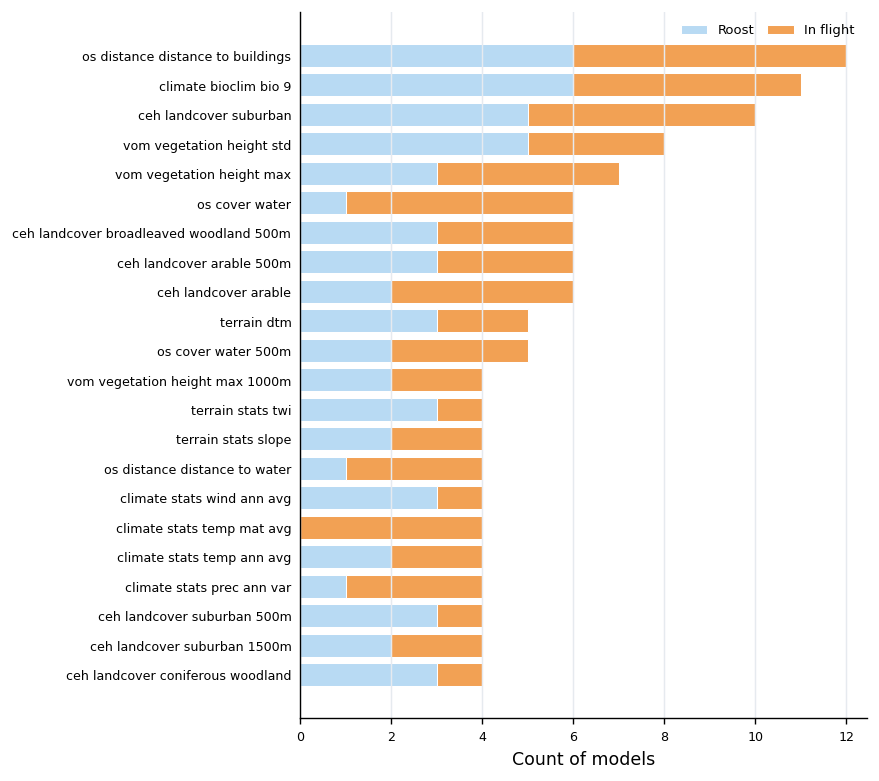

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fitted_keys = set(zip(mr["latin_name"], mr["activity_type"]))
n_roost_fitted = int((mr["activity_type"] == "Roost").sum())
n_inflight_fitted = int((mr["activity_type"] == "In flight").sum())

freq_roost = Counter()
freq_inflight = Counter()
per_model = []

for d in sorted(cfg_dir.iterdir()):
    if not d.is_dir():
        continue
    yp = d / "variables_config.yml"
    if not yp.exists():
        continue
    name = d.name
    if name.endswith("_Roost"):
        act, base = "Roost", name[: -len("_Roost")]
    elif name.endswith("_In_flight"):
        act, base = "In flight", name[: -len("_In_flight")]
    else:
        continue
    latin = base.replace("_", " ")
    if (latin, act) not in fitted_keys:
        continue

    lines = []
    for line in yp.read_text().splitlines():
        if line.strip().startswith("#-"):
            continue
        if line.strip().startswith("#") and "- " in line:
            continue
        lines.append(line)
    data = yaml.safe_load("\n".join(lines)) or {}
    vars_ = [v for v in (data.get("variables") or []) if isinstance(v, str)]
    mid = f"{latin.lower().replace(' ', '_')}_{'roost' if act == 'Roost' else 'in_flight'}"
    if act == "Roost":
        for v in vars_:
            freq_roost[v] += 1
    else:
        for v in vars_:
            freq_inflight[v] += 1
    per_model.append({"model_id": mid, "n_vars": len(vars_), "variables": ", ".join(sorted(vars_))})

per_model_df = pd.DataFrame(per_model).sort_values("model_id").reset_index(drop=True)


def _freq_sorted(counter):
    df = pd.DataFrame(counter.most_common(), columns=["variable", "n_models"])
    return df.sort_values(["n_models", "variable"], ascending=[False, True]).reset_index(drop=True)


roost_tbl = _freq_sorted(freq_roost)
inflight_tbl = _freq_sorted(freq_inflight)


vars_union = sorted(set(freq_roost) | set(freq_inflight))
combo = pd.DataFrame(
    {
        "variable": vars_union,
        "n_roost_models": [freq_roost[v] for v in vars_union],
        "n_inflight_models": [freq_inflight[v] for v in vars_union],
    }
)
combo["n_combined"] = combo["n_roost_models"] + combo["n_inflight_models"]
combo = combo.sort_values(["n_combined", "variable"], ascending=[False, True]).reset_index(drop=True)


freq_all_legacy = freq_roost + freq_inflight
freq_df_legacy = pd.DataFrame(freq_all_legacy.most_common(), columns=["variable", "n_models"])


TOP_PREDICTORS = 22
p = (
    combo.nlargest(TOP_PREDICTORS, "n_combined").sort_values(
        ["n_combined", "variable"], ascending=[True, True]
    )
)
y = np.arange(len(p))
rx, fx = p["n_roost_models"].values, p["n_inflight_models"].values
xm = float((rx + fx).max())
lbl = [s.replace("_", " ") for s in p["variable"]]
BLUE, ORNG = "#b8daf3", "#f2a154"

inch_w, inch_h = 7.75, TOP_PREDICTORS * 0.28 + 0.65
fig, ax = plt.subplots(figsize=(inch_w, inch_h), dpi=125)
kw = dict(height=0.78, edgecolor="#ffffff", linewidth=0.6)
ax.barh(y, rx, label="Roost", color=BLUE, **kw)
ax.barh(y, fx, left=rx, label="In flight", color=ORNG, **kw)

ax.set(yticks=y, yticklabels=lbl)
ax.tick_params(axis="y", length=0, pad=5, labelsize=7.25)
ax.tick_params(axis="x", labelsize=7.25)
ax.set_xlim(0, xm + 0.45)
nt = int(np.ceil(xm))
step = max(2, (nt + 2) // 5)
ax.set_xticks(list(range(0, nt + 2, step)))
ax.grid(axis="x", color="#e6eaef", linewidth=0.85)
ax.spines[["top", "right"]].set_visible(False)

ax.legend(loc="upper right", fontsize=7.6, ncol=2, frameon=False, columnspacing=1.0)
ax.set_xlabel("Count of models")

fig.subplots_adjust(left=0.38, bottom=0.14, top=0.97, right=0.965)

plt.show()



## 7. CV AUC summary


In [8]:
v = mr["mean_cv_score"].dropna()
summary = pd.DataFrame([
    {
        "n_models_with_auc": int(v.shape[0]),
        "min_auc": float(v.min()),
        "max_auc": float(v.max()),
        "median_auc": float(v.median()),
        "mean_auc": float(v.mean()),
        "poorest_model": mr.loc[v.idxmin(), "identifier"],
        "best_model": mr.loc[v.idxmax(), "identifier"],
    }
])
show(summary, "AUC summary")
roost = mr[mr["activity_type"] == "Roost"]["mean_cv_score"].dropna()
flight = mr[mr["activity_type"] == "In flight"]["mean_cv_score"].dropna()
print("Roost      n=%d  median=%.6f  mean=%.6f" % (len(roost), roost.median(), roost.mean()))
print("In flight  n=%d  median=%.6f  mean=%.6f" % (len(flight), flight.median(), flight.mean()))



=== AUC summary ===

   n_models_with_auc   min_auc   max_auc  median_auc  mean_auc                poorest_model                   best_model
0                 16  0.769437  0.900549    0.835451  0.840203  Myotis mystacinus_In flight  Pipistrellus pygmaeus_Roost



,n_models_with_auc,min_auc,max_auc,median_auc,mean_auc,poorest_model,best_model
0,16,0.769437,0.900549,0.835451,0.840203,Myotis mystacinus_In flight,Pipistrellus pygmaeus_Roost


Roost      n=8  median=0.882537  mean=0.864990
In flight  n=8  median=0.817865  mean=0.815416


## 8. SHAP — `shap_importance.png` files


In [9]:
shap_root = REPO / "data/sdm_predictions/visualization/shap"
if shap_root.is_dir():
    paths = sorted(shap_root.rglob("shap_importance.png"))
    print("Count:", len(paths))
    for p in paths:
        print(p.relative_to(REPO))
else:
    print("Missing:", shap_root)


Count: 17
data/sdm_predictions/visualization/shap/Myotis_brandtii/Roost/shap_importance.png
data/sdm_predictions/visualization/shap/Myotis_daubentonii/In_flight/shap_importance.png
data/sdm_predictions/visualization/shap/Myotis_daubentonii/Roost/shap_importance.png
data/sdm_predictions/visualization/shap/Myotis_mystacinus/In_flight/shap_importance.png
data/sdm_predictions/visualization/shap/Myotis_mystacinus/Roost/shap_importance.png
data/sdm_predictions/visualization/shap/Myotis_nattereri/In_flight/shap_importance.png
data/sdm_predictions/visualization/shap/Myotis_nattereri/Roost/shap_importance.png
data/sdm_predictions/visualization/shap/Nyctalus_leisleri/In_flight/shap_importance.png
data/sdm_predictions/visualization/shap/Nyctalus_leisleri/Roost/shap_importance.png
data/sdm_predictions/visualization/shap/Nyctalus_noctula/In_flight/shap_importance.png
data/sdm_predictions/visualization/shap/Nyctalus_noctula/Roost/shap_importance.png
data/sdm_predictions/visualization/shap/Pipistrell

## 9. Prediction rasters — `prediction_*.tif`


In [10]:
pred_dir = REPO / "data/sdm_predictions"
tif = sorted(pred_dir.glob("prediction_*.tif"))
print("Count:", len(tif))
for p in tif:
    print(p.name)


Count: 19
prediction_myotis_brandtii_roost.tif
prediction_myotis_daubentonii_in_flight.tif
prediction_myotis_daubentonii_roost.tif
prediction_myotis_mystacinus_in_flight.tif
prediction_myotis_mystacinus_roost.tif
prediction_myotis_nattereri_in_flight.tif
prediction_myotis_nattereri_roost.tif
prediction_nyctalus_leisleri_in_flight.tif
prediction_nyctalus_leisleri_roost.tif
prediction_nyctalus_noctula_in_flight.tif
prediction_nyctalus_noctula_roost.tif
prediction_nyctalus_noctula_roost_epsg3857.tif
prediction_nyctalus_noctula_roost_epsg3857_cog.tif
prediction_pipistrellus_pipistrellus_in_flight.tif
prediction_pipistrellus_pipistrellus_roost.tif
prediction_pipistrellus_pygmaeus_in_flight.tif
prediction_pipistrellus_pygmaeus_roost.tif
prediction_plecotus_auritus_in_flight.tif
prediction_plecotus_auritus_roost.tif
